# Laboratorio de regresión logística

|                |   |
:----------------|---|
| **Nombre**     |Diana Fernanda Barbosa Dueñas   |
| **Fecha**      |9/marzo/2026   |
| **Expediente** |756920   |

La regresión logística es una herramienta utilizada para predecir respuestas cualitativas. Al igual que la regresión lineal, es un método sencillo que sirve como un punto de partida para técnicas más avanzadas. Por ejemplo, lo que se conoce como *redes neuronales* o *red de perceptrones multicapa* no es más que una estructura de regresiones logísticas que se alimentan entre sí.

1. Descarga el archivo de créditos y carga los datos (Default.csv). Utiliza `pandas`.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Default.csv to Default.csv


In [3]:
import pandas as pd
default = pd.read_csv("Default.csv")

2. Utiliza el comando `obj.head()`, donde `obj` es el nombre que le diste a los datos del archivo.

In [9]:
default.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


El comando head arroja los primeras *n* líneas (por defecto 5) de los datos que están en el DataFrame.

3. Utiliza el comando `obj.describe()`.

In [10]:
default.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729275
max,2654.322576,73554.233500


El comando describe toma las columnas que tienen datos numéricos y saca datos estadísticos comunes:
- *n*
- media
- desviación estándar
- valor mínimo
- primer cuartil
- mediana
- tercer cuartil
- valor máximo

3. Vistos estos datos, ¿qué columnas existen en el DataFrame? ¿Qué tipo de datos contienen?

Podemos ver un resumen general de los datos de balance e income. En total hay 10,000 registros y se muestran valores como el promedio, el mínimo, el máximo y qué tan dispersos están los datos.
En el balance el promedio es de aproximadamente 835, mientras que el ingreso promedio es de alrededor de 33,517, lo que nos da una idea general de cómo se comportan estos datos.

4. Configura el tipo de dato de las columnas `default` y `student` para cambiarlos a variables categóricas.

`data[columna] = data[columna].astype("category")`

In [11]:
default["default"] = default["default"].astype("category")
default["student"] = default["student"].astype("category")

Imagina que trabajas en un banco y que se te entregan estos datos. Tu objetivo es crear un modelo que ayude a predecir si una persona que solicita un crédito lo va a pagar. Exploremos los datos un poco más antes de crear un modelo.

Veamos primero cómo es la distribución de los valores cuando una persona dejó de pagar y cuando siguió pagando. `Default` es el término utilizado para cuando una persona dejó de pagar.

5. Crea una gráfica de caja para las columnas `income` y `balance`, con los datos agrupados con la columna `default`. Utiliza el comando `obj.boxplot(column=____, by=_____)`

<Axes: title={'center': 'income'}, xlabel='default'>

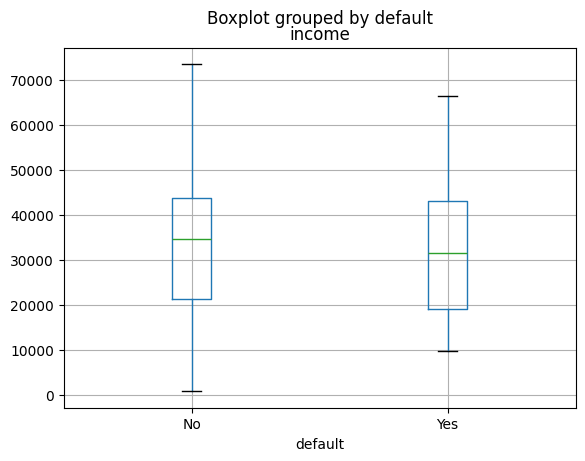

In [12]:
default.boxplot(column="income", by="default")

6. Crea una gráfica de dispersión donde el eje *x* sea la columna `balance` y el eje *y* la columna `income`. Utiliza el comando `obj.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)`.

In [19]:
x = "balance"
y = "income"

<Axes: xlabel='balance', ylabel='income'>

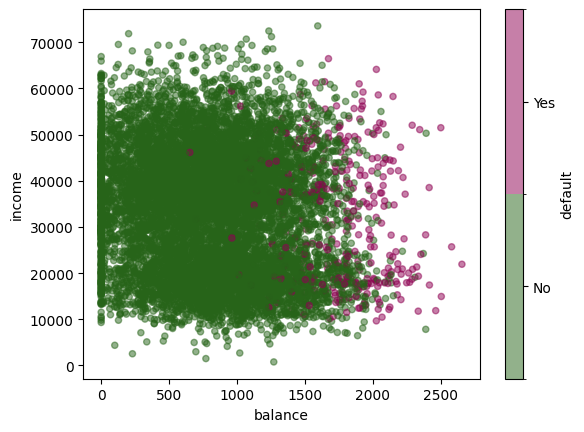

In [20]:
default.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)

La regresión (lineal o logística) se usa para encontrar una línea que ajuste los datos para tomar una decisión. La línea que buscamos en regresión logística es aquella que nos ayude a separar las diferentes categorías.

<img style="float: left; " src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/decision_boundary_curve.jpg" width="400px" />


## Regresión logística simple

Creemos un modelo simple donde sólo utilizamos una de los factores para predecir una respuesta. Quiero conocer la probabilidad de que una persona deje de pagar su crédito dado el balance que tiene en su cuenta.

$$ P(\text{default}=\text{Yes}|\text{balance}) $$

Por el momento la columna default no contiene valores numéricos, por lo que hay que transformar los datos. Como default es nuestra variable de respuesta (lo que queremos predecir) podemos nombrarla *y*.

Ejecuta el código `y = obj["default"] == "Yes"`. Extrae el factor `balance` en una variable *x*.

In [30]:
y2 = default["default"] == "Yes"

In [31]:
x2 = default["balance"]

Crea un gráfico de dispersión donde el eje *x* sea `balance` y el eje *y* sea `default` transformado.

<Axes: xlabel='balance', ylabel='default_transformed'>

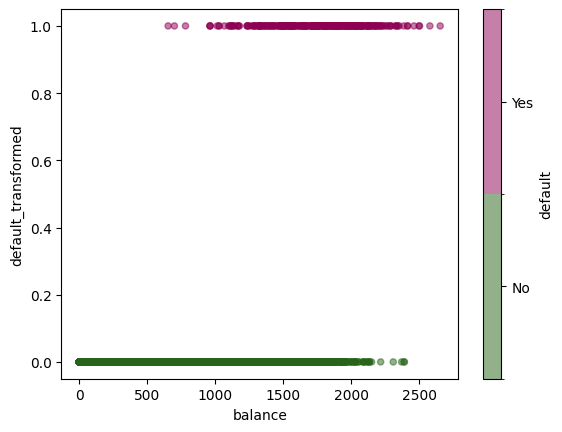

In [40]:
import matplotlib.pyplot as plt

default['default_transformed'] = y2.astype(int)
default.plot.scatter(x="balance", y="default_transformed", c="default", colormap="PiYG_r", alpha=0.5)

La línea que utilizaremos para predecir la probabilidad es:

$$ p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}} $$

Para nuestro ejemplo de pagos y balance:

$$ P(\text{default}=1|\text{balance}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance})}} $$

Buscamos maximizar la probabilidad de que el modelo tome decisiones correctas. Es decir, que cuando `default` fue verdadero, que la predicción sea 100%, y que cuando `default` fue falso que la predicción sea 0%.

$$ \Pi_{i:y_i=1} p(x_i) \Pi_{i':y_{i'}} (1-p(x_{i'})) $$

La función de costo ya simplificada es la siguiente:

$$ J(\vec{\beta}) = -  \sum_{i=1}^n{[y_i \ln{(\hat{p}(x_i))} + (1-y_i)\ln{(1 - \hat{p}(x_i))}]}$$

Utiliza la clase `LogisticRegression` del módulo `linear_model` de la librería `sklearn` para estimar los parámetros del modelo.

In [41]:
from sklearn.linear_model import LogisticRegression

In [43]:
lr = LogisticRegression()
lr.fit(x2.values.reshape(-1, 1), y2)

LogisticRegression()

In [45]:
lr.coef_, lr.intercept_

(array([[0.00549892]]), array([-10.65132824]))

Nuestra formula quedaría como:

**y = -10.65x + 0.005**

Muchos aspectos de la regresión logística son similares a la regresión lineal. Podemos medir la precisión de nuestros estimados calculando sus errores estándar. El objetivo de calcular estos errores es asegurar que hay una relación estadísticamente significativa entre el factor y la variable de respuesta.

Los errores estándar se obtienen con el siguiente procedimiento:

1. Calcula las predicciones utilizando los $\beta_0$ y $\beta_1$ encontrados.

In [46]:
import numpy as np

In [47]:
beta0 = lr.intercept_
beta1 = lr.coef_

In [51]:
pred = 1 / (1 + np.exp(-(beta0 + beta1 * x2.values)))
pred

array([[1.30568146e-03, 2.11259754e-03, 8.59474814e-03, ...,
        2.46651596e-03, 1.16759635e-01, 7.14476480e-05]])

In [52]:
var = pred * (1 - pred)
var

array([[1.30397665e-03, 2.10813447e-03, 8.52087844e-03, ...,
        2.46043226e-03, 1.03126823e-01, 7.14425432e-05]])

2. Idealmente la probabilidad debería ser 100% o 0%. Si alguna predicción no fue absoluta significa que hay incertidumbre. Calcula $p(1-p)$ para todas tus predicciones.

In [53]:
var_pred = pred * (1 - pred)
var_pred

array([[1.30397665e-03, 2.10813447e-03, 8.52087844e-03, ...,
        2.46043226e-03, 1.03126823e-01, 7.14425432e-05]])

3. Crea una matriz vacía y llena la diagonal con las probabilidades encontradas.

`V = np.diagflat(*p(1-p)*)`

In [54]:
V = np.diagflat(var_pred)
V

array([[1.30397665e-03, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 2.10813447e-03, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 8.52087844e-03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        2.46043226e-03, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.03126823e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 7.14425432e-05]])

4. Calcula la matriz de covarianza. (Dado que X es la matriz que contiene todos los factores)

`cov = np.linalg.inv(X.T @ V @ X)`

In [60]:
X = np.array(x2.values).reshape(-1, 1)
X

array([[ 729.52649521],
       [ 817.1804066 ],
       [1073.549164  ],
       ...,
       [ 845.4119892 ],
       [1569.00905338],
       [ 200.92218263]])

In [61]:
cov = np.linalg.inv(X.T @ V @ X)
cov

array([[1.71411499e-09]])

5. Los valores en la diagonal de la matriz de covarianza corresponden a la varianza de los factores. Utiliza los valores de la diagonal para calcular el error estándar.

`se = np.sqrt(np.diag(cov))`

In [63]:
se = np.sqrt(np.diag(cov))
se

array([4.14018718e-05])

Ahora, revisemos si los estimados de nuestros coeficientes demuestran que hay una relación significativa entre los factores y la respuesta.

Calculamos el estadístico *z*

$$ z_j = \frac{\hat{\beta_j}}{\text{SE}(\hat{\beta_j})} $$

Utilizamos el estadístico *z* para encontrar el *p-value*.

`from scipy.stats import norm`

`p_value = 2 * (1 - norm.cdf(abs(z_statistic)))`

In [76]:
from scipy.stats import norm
import numpy as np

In [80]:
z_beta0 = beta0[0] / se_corrected[0]
z_beta1 = beta1[0,0] / se_corrected[1]

z_beta0, z_beta1

(np.float64(-29.491290894464125), np.float64(24.952405517879775))

In [78]:
# p-values (dos colas)
p_value_beta0 = 2 * (1 - norm.cdf(abs(z_beta0)))
p_value_beta1 = 2 * (1 - norm.cdf(abs(z_beta1)))

p_value_beta0, p_value_beta1

(np.float64(0.0), np.float64(0.0))

¿Es significativa la relación de los factores con la variable de respuesta?

Si, ya que si mi p‑value es muy pequeño, significa que el balance sí tiene una relación significativa con la probabilidad de default.

Repite el procedimiento con el factor `student`.
1. Transforma el factor de {"Yes", "No"} a {1, 0}.
2. Estima los coeficientes.
3. Calcula el error estándar de tus estimaciones.
   1. Usa tu modelo para encontrar $\hat{p}(X)$
   2. Calcula el error $p(1-p)$
   3. Calcula la matriz de covarianza
   4. Extrae el error estándar
5. Argumenta si los factores son significativos utilizando el *p-value*.
   1. Utiliza el error estándar para calcular el estadístico *z*
   2. Calcula el *p-value*
   3. ¿Son significativos?


In [12]:
import numpy as np

In [4]:
y_student = default["student"] == "Yes"
x_student = default["balance"]

In [7]:
from sklearn.linear_model import LogisticRegression
lr_student = LogisticRegression()
lr_student.fit(x_student.values.reshape(-1, 1), y_student)
lr_student.intercept_, lr_student.coef_

(array([-1.70042237]), array([[0.00094086]]))

In [10]:
pred_student = lr_student.predict_proba(x_student.values.reshape(-1, 1))[:, 1]
var_student = pred_student * (1 - pred_student)

In [19]:
X_design_student = np.hstack([np.ones((x_student.shape[0], 1)), x_student])

V_student = np.diagflat(var_student)

cov_student = np.linalg.inv(X_design_student.T @ V_student @ X_design_student)

se_student = np.sqrt(np.diag(cov_student))

In [18]:
cov_student
se_student

array([4.87776603e-02, 4.72105573e-05])

In [23]:
from scipy.stats import norm

beta0_student = lr_student.intercept_
beta1_student = lr_student.coef_

z_beta0_student = beta0_student[0] / se_student[0]
z_beta1_student = beta1_student[0][0] / se_student[1]

p_value_beta0_student = 2 * (1 - norm.cdf(abs(z_beta0_student)))
p_value_beta1_student = 2 * (1 - norm.cdf(abs(z_beta1_student)))

z_beta0_student, z_beta1_student
p_value_beta0_student, p_value_beta1_student

(np.float64(0.0), np.float64(0.0))

- Si el p‑value < 0.05, el coeficiente es significativo.

- Lo que interesa aquí es el coeficiente student (β1): si su p‑value es pequeño, significa que ser estudiante sí influye en la probabilidad de default.

- Si el p‑value es grande, entonces no hay evidencia estadística de que el factor sea relevante.

## Regresión logística múltiple

Considera ahora el caso de múltiples factores. Intentemos predecir si la persona dejará de pagar su crédito utilizando toda la información que tenemos disponible. I.e.

$$ P(\text{default}=1|\text{balance}, \text{income}, \text{student}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance} + \beta_2 \text{income} + \beta_3 \text{student})}} $$

1. Utiliza `LogisticRegression` para estimar los coeficientes.
2. Calcula el error estándar de tus estimaciones.
3. Argumenta si los factores son significativos utilizando el *p-value*.

In [25]:
from sklearn.linear_model import LogisticRegression

# Variables predictoras: balance, income y student (transformado a 0/1)
X_multi = default[["balance", "income"]].copy()
X_multi["student"] = (default["student"] == "Yes").astype(int)

# Variable respuesta
y_multi = (default["default"] == "Yes").astype(int)

# Ajustar el modelo
lr_multi = LogisticRegression()
lr_multi.fit(X_multi, y_multi)

# Coeficientes
beta0_multi = lr_multi.intercept_[0]
betas_multi = lr_multi.coef_[0]

beta0_multi, betas_multi

(np.float64(-10.901807847686797),
 array([ 5.73061109e-03,  3.96163258e-06, -6.12572807e-01]))

In [28]:
# Predicciones
pred_multi = lr_multi.predict_proba(X_multi)[:,1]

# p(1-p)
varianza_pred_multi = pred_multi * (1 - pred_multi)

# Matriz X con intercepto
X_design = np.column_stack((np.ones(len(X_multi)), X_multi))

# Matriz V y covarianza
V_multi = np.diagflat(varianza_pred_multi)
cov_multi = np.linalg.inv(X_design.T @ V_multi @ X_design)

# Errores estándar
se_multi = np.sqrt(np.diag(cov_multi))
se_multi


array([4.93158470e-01, 2.31675571e-04, 8.20844359e-06, 2.36393913e-01])

In [29]:
from scipy.stats import norm

# Estadísticos z
z_values = np.array([beta0_multi] + list(betas_multi)) / se_multi

# p-values
p_values = 2 * (1 - norm.cdf(np.abs(z_values)))

# Mostrar resultados en tabla
print("Coeficiente   SE        z        p-value")
labels = ["Intercepto", "Balance", "Income", "Student"]
for lbl, coef, se, z, p in zip(labels, [beta0_multi]+list(betas_multi), se_multi, z_values, p_values):
    print(f"{lbl:10} {coef:.4f}   {se:.4f}   {z:.4f}   {p:.4e}")

Coeficiente   SE        z        p-value
Intercepto -10.9018   0.4932   -22.1061   0.0000e+00
Balance    0.0057   0.0002   24.7355   0.0000e+00
Income     0.0000   0.0000   0.4826   6.2936e-01
Student    -0.6126   0.2364   -2.5913   9.5608e-03


¿Cómo sabemos qué tan bueno es el modelo? Hay cuatro posibles casos para un problema de clasificación simple:
- Era sí y se predijo sí. (Verdadero positivo **TP**)
- Era sí y se predijo no. (Falso negativo **FN**)
- Era no y se predijo sí. (Falso positivo **FP**)
- Era no y se predijo no. (Verdadero negativo **TN**)

De esos cuatro casos hay dos donde el modelo es correcto y dos donde el modelo no es correcto.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*IuymDnZpRlkat0qejE26Nw.png)

1. Menciona dos ejemplos donde consideres que un falso positivo sea un peor resultado que un falso negativo.

Un caso claro es en el diagnóstico médico de enfermedades graves. Si un sistema dice que una persona tiene cáncer cuando en realidad no lo tiene, puede causarle mucho estrés, hacer que pase por tratamientos innecesarios y además generar gastos muy altos.

Otro ejemplo es en la detección de fraude en tarjetas de crédito: si el sistema marca una compra normal como fraude, el cliente puede quedarse sin poder usar su dinero por un tiempo y hasta perder confianza en el banco.

2. Menciona dos ejemplos donde consideres que un falso negativo sea un peor resultado que un falso positivo.

Un ejemplo sería un sistema de alarma contra incendios. Si no detecta un incendio real, las consecuencias pueden ser muy graves porque las personas no recibirían la alerta a tiempo.

Algo parecido pasa en la seguridad de los aeropuertos: si un objeto peligroso no es detectado y logra pasar, se pone en riesgo la seguridad de todos los pasajeros.

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3